In [7]:
import pandas as pd
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [2]:
df = pd.read_csv("../data/logs.csv")
df.head()

,timestamp,level,service,message,response_time_ms,status_code,is_anomaly
0,2026-04-21 17:31:56.732407,INFO,notification-service,Database query executed in 499ms,499,200,False
1,2026-04-21 17:36:56.732407,INFO,notification-service,Connection timeout after 7121ms,7121,500,True
2,2026-04-21 17:49:29.732407,INFO,inventory-service,Cache hit for key,640,200,False
3,2026-04-21 17:49:37.732407,INFO,auth-service,User authenticated,328,200,False
4,2026-04-21 17:52:03.732407,INFO,notification-service,Cache hit for key,505,200,False


In [5]:
print("Shape:", df.shape)

print("\nData Types:")
print(df.info())

print("\nFirst 5 Rows:")
display(df.head())

print("\nMissing values:")
print(df.isnull().sum())

Shape: (10000, 7)

Data Types:
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   timestamp         10000 non-null  str  
 1   level             10000 non-null  str  
 2   service           10000 non-null  str  
 3   message           10000 non-null  str  
 4   response_time_ms  10000 non-null  int64
 5   status_code       10000 non-null  int64
 6   is_anomaly        10000 non-null  bool 
dtypes: bool(1), int64(2), str(4)
memory usage: 478.6 KB
None

First 5 Rows:


,timestamp,level,service,message,response_time_ms,status_code,is_anomaly
0,2026-04-21 17:31:56.732407,INFO,notification-service,Database query executed in 499ms,499,200,False
1,2026-04-21 17:36:56.732407,INFO,notification-service,Connection timeout after 7121ms,7121,500,True
2,2026-04-21 17:49:29.732407,INFO,inventory-service,Cache hit for key,640,200,False
3,2026-04-21 17:49:37.732407,INFO,auth-service,User authenticated,328,200,False
4,2026-04-21 17:52:03.732407,INFO,notification-service,Cache hit for key,505,200,False



Missing values:
timestamp           0
level               0
service             0
message             0
response_time_ms    0
status_code         0
is_anomaly          0
dtype: int64


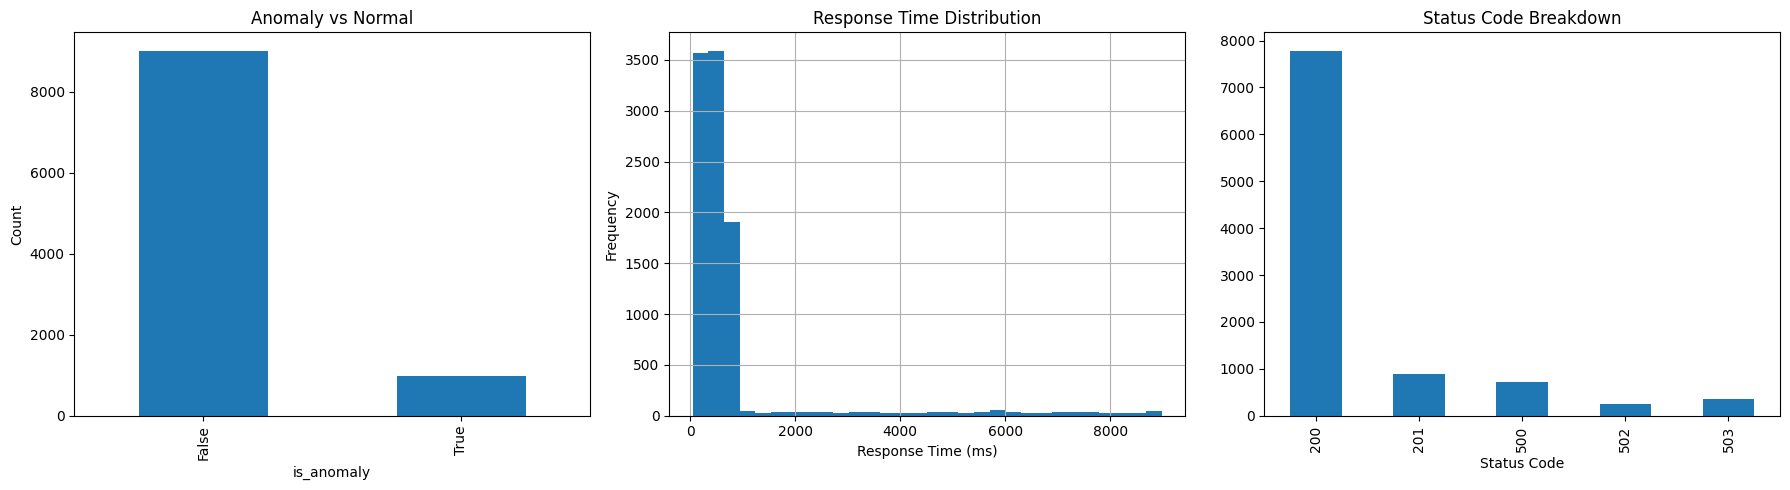

In [14]:
plt.figure(figsize=(18,5))

# --- Anomaly vs Normal ---
plt.subplot(1,3,1)
df["is_anomaly"].value_counts().plot(kind="bar")
plt.title("Anomaly vs Normal")
plt.ylabel("Count")

# --- Response time distribution ---
plt.subplot(1,3,2)
df["response_time_ms"].hist(bins=30)
plt.title("Response Time Distribution")
plt.xlabel("Response Time (ms)")
plt.ylabel("Frequency")

# --- Status code breakdown ---
plt.subplot(1,3,3)
df["status_code"].value_counts().sort_index().plot(kind="bar")
plt.title("Status Code Breakdown")
plt.xlabel("Status Code")

plt.tight_layout()
plt.show()

In [15]:
print("Anomaly Counts:")
print(df["is_anomaly"].value_counts())

print("\nStatus Code Counts:")
print(df["status_code"].value_counts())

print("\nResponse Time Summary:")
display(df["response_time_ms"].describe())

Anomaly Counts:
is_anomaly
False    9023
True      977
Name: count, dtype: int64

Status Code Counts:
status_code
200    7785
201     882
500     723
503     364
502     246
Name: count, dtype: int64

Response Time Summary:


count    10000.000000
mean       849.526200
std       1516.944098
min         50.000000
25%        258.000000
50%        465.000000
75%        677.000000
max       8981.000000
Name: response_time_ms, dtype: float64

In [16]:
df.groupby("is_anomaly")["response_time_ms"].describe()

,count,mean,std,min,25%,50%,75%,max
is_anomaly,,,,,,,,
False,9023.0,425.643467,218.025469,50.0,237.0,427.0,614.0,800.0
True,977.0,4764.258956,2476.561216,602.0,2556.0,4857.0,6943.0,8981.0
